In [113]:
from skimage import io, color, morphology, measure, img_as_ubyte, img_as_float
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb
from scipy.ndimage import correlate
from skimage.measure import profile_line
from skimage.transform import rescale, resize
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np

In [114]:
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.imshow(original)
    ax1.set_title("Original")
    ax1.axis("off")
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis("off")
    io.show()

((1119, 2077), <matplotlib.image.AxesImage at 0x7f7f30e53640>)

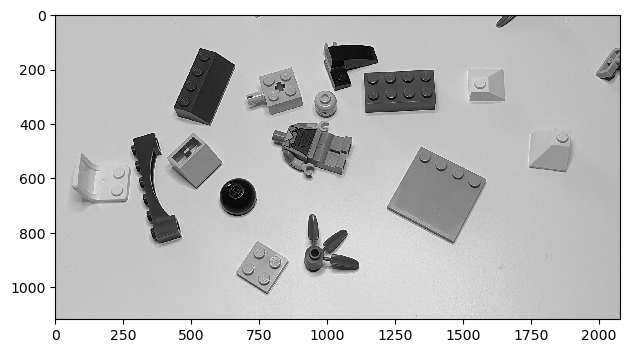

In [115]:
folder_path = "data/"
lego_img = rgb2gray(io.imread(folder_path + "lego_4_small.png"))
lego_img.shape, io.imshow(lego_img)

## Binary thresholding

In [116]:
def threshold_image(img: np.array, thresh: float):
    """
    Obtains a threshold image

    Args:
        img (np.array): input image
        threshold (float): gamma coefficient

    Return:
        threshold_img (np.array): newly mapped image
    """
    return img > thresh

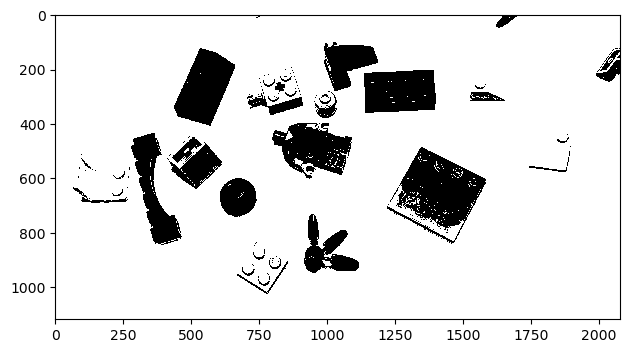

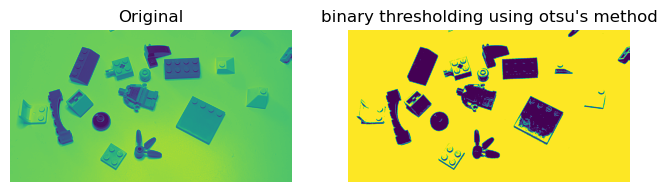

In [117]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(lego_img)
otsu_img = threshold_image(lego_img, threshold)
io.imshow(otsu_img)
show_comparison(lego_img, otsu_img, "binary thresholding using otsu's method")

## Remove border BLOBS
In scikit-image’s segmentation.clear_border function, the mask parameter doesn’t inherently define the borders—it’s an optional input that specifies which regions of the image should be protected or considered when deciding what to clear. By default, clear_border removes objects (connected components in a binary image) that touch the image borders. The mask modifies this behavior:

Without a mask: All objects touching the border are removed.
With a mask: Objects touching the border are still candidates for removal, but only if they overlap with True regions of the mask. Objects overlapping with False regions in the mask are ignored entirely, border or not.

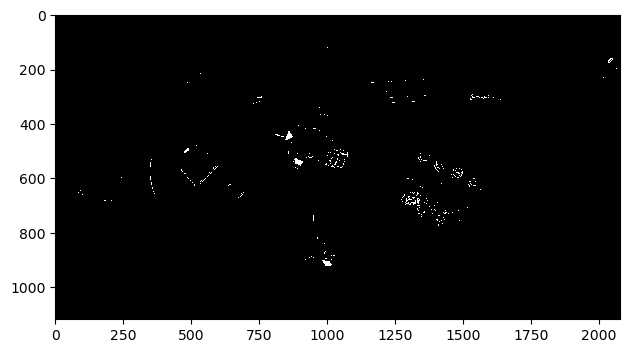

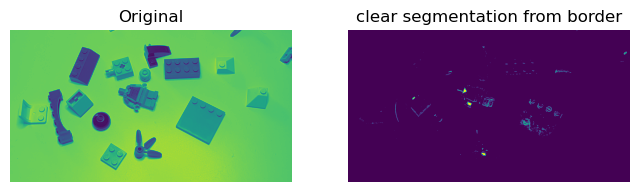

In [118]:
otsu_img = segmentation.clear_border(otsu_img)
io.imshow(otsu_img)
show_comparison(lego_img, otsu_img, "clear segmentation from border")

## Morphological open and close
In order to remove remove noise and close holes, you should do a morphological closing followed by a morphological opening with a disk shaped structuring element with radius 5.

In [119]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk

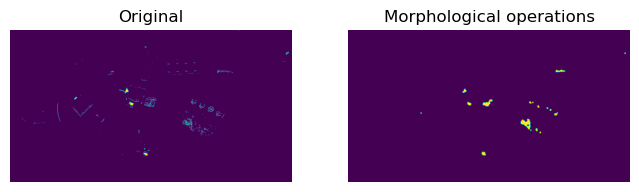

In [120]:
footprint = disk(5)
morphed_img = opening(closing(otsu_img, footprint), footprint)
show_comparison(otsu_img, morphed_img, "Morphological operations")

## Connected component analysis / BLOB analysis

In [121]:
label_img = measure.label(morphed_img)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")

Number of labels: 17


/home/monkescripts/anaconda3/envs/course02502/lib/python3.9/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning:

Low image data range; displaying image with stretched contrast.



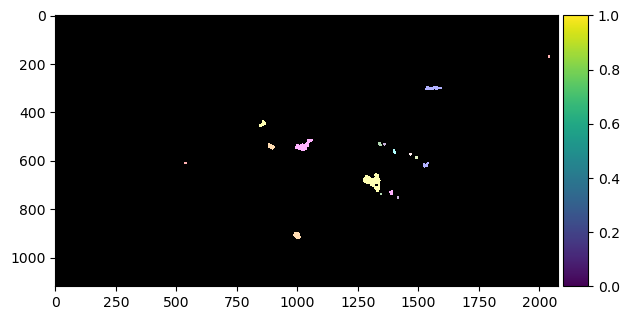

In [122]:
annotated_img = label2rgb(label_img, morphed_img)
io.imshow(annotated_img)

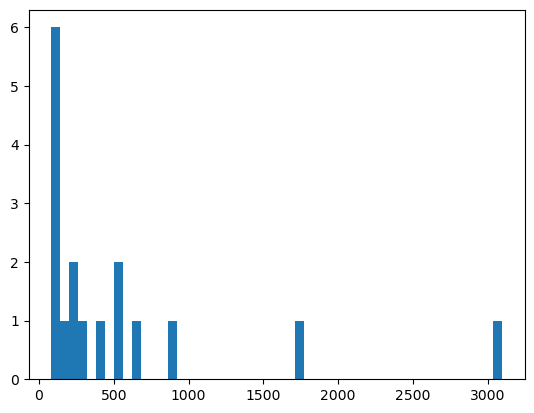

In [123]:
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()

In [124]:
# %conda install -c plotly plotly=6.0.0 -y

In [125]:
# Modified sligthly from
# https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_regionprops.html
import plotly
import plotly.express as px
import plotly.graph_objects as go
from skimage import data, filters, measure, morphology, io, color

# spyder fix
import plotly.io as pio

pio.renderers.default = "browser"


def interactive_blobs():
    in_dir = "data/"
    im_name = "lego_4_small.png"

    img_org = io.imread(in_dir + im_name)
    img = color.rgb2gray(img_org)
    # Binary image, post-process the binary mask and compute labels
    threshold = filters.threshold_otsu(img)
    mask = img < threshold
    mask = morphology.remove_small_objects(mask, 50)
    mask = morphology.remove_small_holes(mask, 50)
    labels = measure.label(mask)

    fig = px.imshow(img, binary_string=True)
    fig.update_traces(hoverinfo="skip")  # hover is only for label info

    props = measure.regionprops(labels, img)
    properties = ["area", "eccentricity", "perimeter", "intensity_mean"]

    # For each label, add a filled scatter trace for its contour,
    # and display the properties of the label in the hover of this trace.
    for index in range(1, labels.max()):
        label_i = props[index].label
        contour = measure.find_contours(labels == label_i, 0.5)[0]
        y, x = contour.T
        hoverinfo = ""
        for prop_name in properties:
            hoverinfo += (
                f"<b>{prop_name}: {getattr(props[index], prop_name):.2f}</b><br>"
            )
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                name=label_i,
                mode="lines",
                fill="toself",
                showlegend=False,
                hovertemplate=hoverinfo,
                hoveron="points+fills",
            )
        )

    plotly.io.show(fig)


if __name__ == "__main__":
    interactive_blobs()

## Cell counting
The goal of this part of the exercise, is to create a small program that can automatically count the number of cell nuclei in an image.

The images used for the exercise is acquired by the Danish company Chemometec using their image-based cytometers. A cytometer is a machine used in many laboratories to do automated cell counting and analysis. An example image can be seen in below where U2OS cells (human bone cells) have been imaged using ultraviolet (UV) microscopy and a fluorescent staining method named DAPI. Using DAPI staining only the cell nuclei are visible which makes the method very suitable for cell counting.

In [126]:
# %conda install imagecodecs -y

To make it easier to develop the cell counting program we start by working with smaller areas of the raw images. The images are also converted to 8 bit grayscale images:

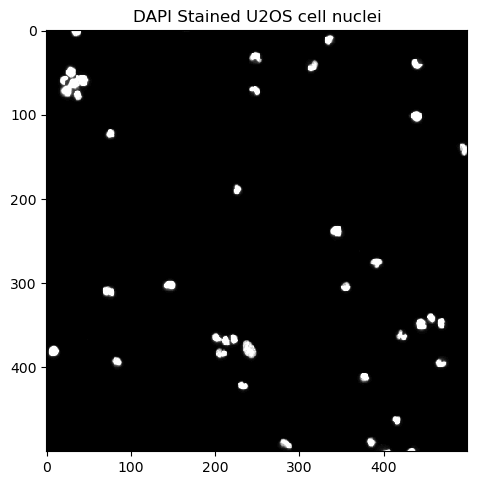

In [127]:
in_dir = "data/"
img_org = io.imread(in_dir + "Sample E2 - U2OS DAPI channel.tiff")
# slice to extract smaller image
img_small = img_org[700:1200, 900:1400]
img_gray = img_as_ubyte(img_small)
io.imshow(img_gray, vmin=0, vmax=40)
plt.title("DAPI Stained U2OS cell nuclei")
io.show()

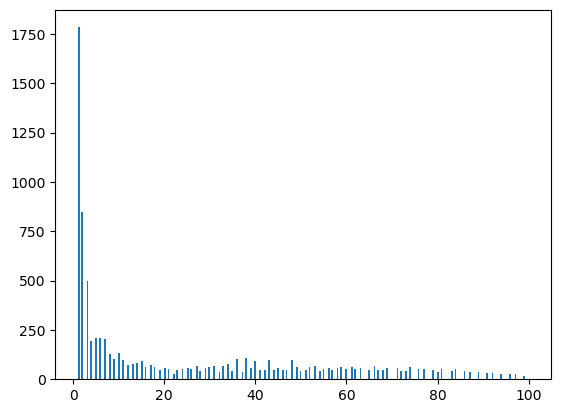

In [128]:
# Find a good threshold using histogram
# avoid bin with value 0 due to the very large number of background pixels
plt.hist(img_gray.ravel(), bins=256, range=(1, 100))
io.show()

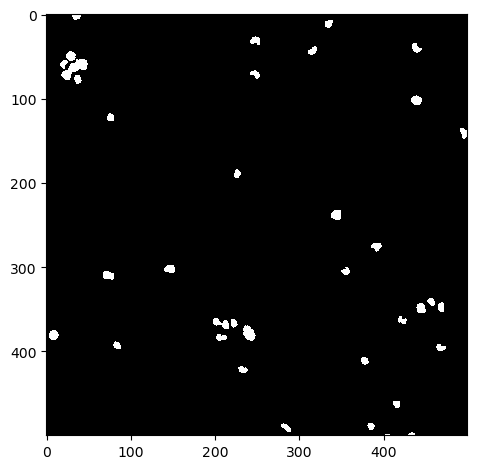

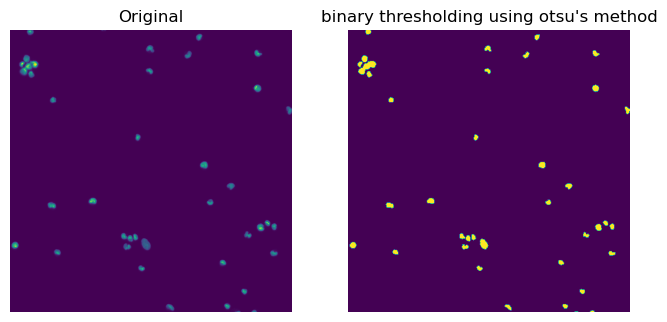

In [129]:
threshold = threshold_otsu(img_gray)
otsu_img = threshold_image(img_gray, threshold)
io.imshow(otsu_img)
show_comparison(img_gray, otsu_img, "binary thresholding using otsu's method")

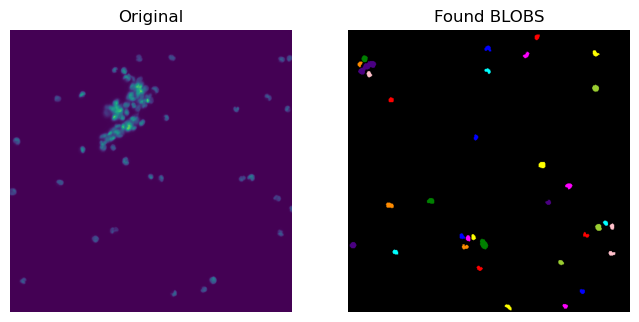

In [130]:
img_c_b = segmentation.clear_border(otsu_img)
label_img = measure.label(img_c_b)
image_label_overlay = label2rgb(label_img)
show_comparison(img_org, image_label_overlay, "Found BLOBS")

In [131]:
region_props = measure.regionprops(label_img)

(34,)


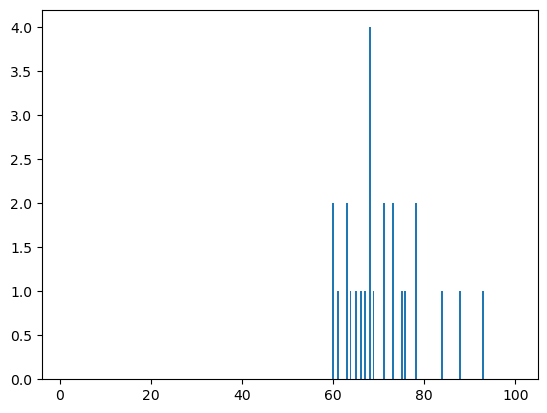

In [132]:
areas = np.array([prop.area for prop in region_props])
print(areas.shape)
plt.hist(areas.ravel(), bins=256, range=(1, 100))
io.show()

## BLOB classification by area

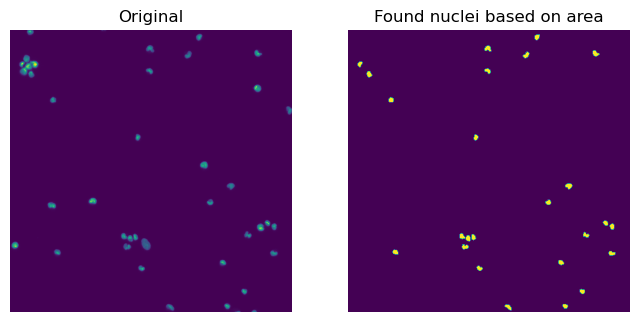

In [133]:
# Select a minimum and maximum allowed area and use the following to visualise the result:
min_area = 60
max_area = 95

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
	# Find the areas that do not fit our criteria
	if region.area > max_area or region.area < min_area:
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_small, i_area, 'Found nuclei based on area')

## Feature space

In [134]:
perimeters = np.array([prop.perimeter for prop in region_props])
perimeters.shape

(34,)

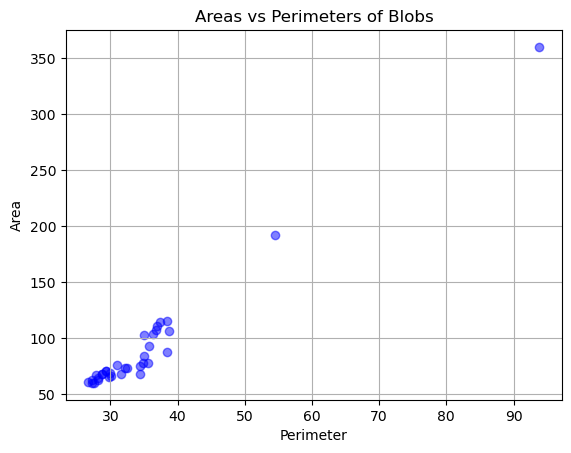

In [135]:
plt.scatter(perimeters, areas, c="blue", alpha=0.5)
plt.xlabel("Perimeter")
plt.ylabel("Area")
plt.title("Areas vs Perimeters of Blobs")
plt.grid(True)
plt.show()

## Compute circularity

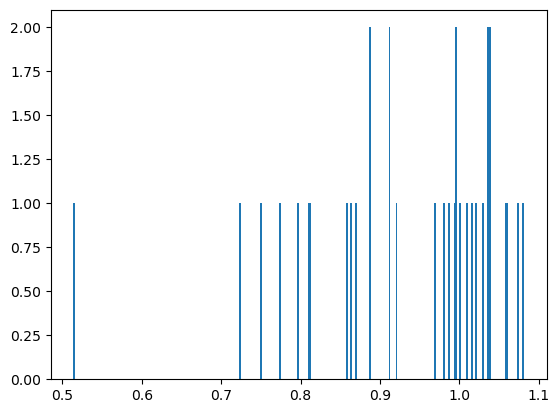

In [136]:
circ = []
num_cells = len(perimeters)
for i in range(num_cells):
    circularity = 4 * np.pi * areas[i] / (perimeters[i]**2)
    circ.append(circularity)
plt.hist(circ, bins=256)
plt.show()

num blobs 17


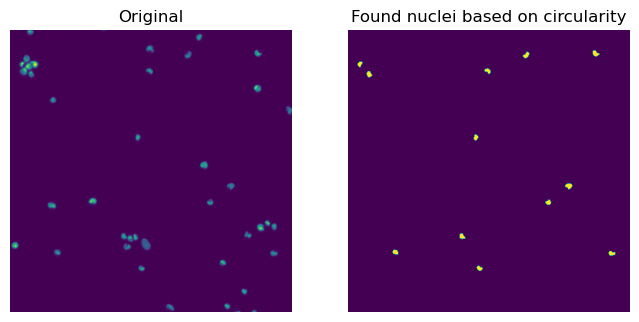

In [137]:
# Select a minimum and maximum allowed circularity and use the following to visualise the result:
min_circularity = 0.8
max_circularity = 1.0

# Create a copy of the label_img
label_img_filter = label_img
count = 0
for region in region_props:
    # Find the areas that do not fit our criteria
    circularity = 4 * np.pi * region.area / (region.perimeter**2)
    if circularity > max_circularity or circularity < min_circularity:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0
    else:
        count += 1
# Create binary image from the filtered label image
i_circularity = label_img_filter > 0
print(f"num blobs {count}")
show_comparison(img_small, i_circularity, "Found nuclei based on circularity")